Environment Requirement: python 3.8; ipykernel, hfst_dev, graphviz

## Setup

In [1]:
import hfst_dev as hfst
import graphviz
import math

In [2]:
# Weights are negative log probabilities
print(-math.log(0.25))
print(-math.log(0.75))
print(-math.log(0.5))

1.3862943611198906
0.2876820724517809
0.6931471805599453


In [3]:
print(-math.log(0.375)) # 3/8
print(-math.log(0.125)) # 1/8
print(-math.log(0.625)) # 5/8
print(-math.log(0.875)) # 7/8

0.9808292530117262
2.0794415416798357
0.4700036292457356
0.13353139262452263


## States

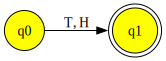

In [4]:
H = hfst.regex('H')
T = hfst.regex('T')
  
# H is unweighted. The initial world H will be iH.
defs = {"H":H,"T":T}

St = hfst.regex('H | T',definitions=defs)
defs.update({"St":St})
St.view()

In [5]:
# State complement
# X is a compiled machine that is assumed to be a set of states.
def Nst(X):
    nst = St.copy()
    nst.minus(X)
    return(nst)

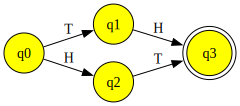

In [6]:
# Read this without definitions
UnequalStPair = hfst.regex("[H T] | [T H]")
defs.update({"UnequalStPair":UnequalStPair})
UnequalStPair.view()

## Identies 
Id is the multiplicative identity of the algebra.

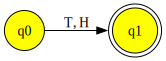

In [7]:
# This is unweighted
# Don't use defs here
Id = hfst.regex('H | T')
Id.view()

### Weighted identities
These can be used to add weights to events, using Cn.

In [8]:
def weighted_id(num,dem):
    weight = -math.log(num / dem)
    machine = hfst.regex(f'H::{weight} | T::{weight}')
    return(machine)

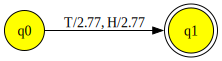

In [9]:
Id_1_16 = weighted_id(1,16)
Id_3_16 = weighted_id(3,16)
Id_4_16 = weighted_id(4,16)
Id_1_16.view()
# With Cn, these will have the effect of multiplying the weight of each path by num/dem.

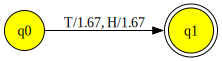

In [10]:
Id_3_16.view()

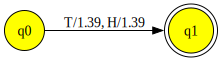

In [11]:
Id_4_16.view()

## Actions
Actions are there in unweighted and weighted versions.  Unweighted is marked with u at the end.
This defines the unweighted decorated events.

In [12]:
# Peeking is going to be construed as fallible
# Accurate peeks, probability will be 3/16
peekamyHHu = hfst.regex('[H peekamyHH H]',definitions=defs) # Amy peeks at H, perceiving H
peekamyTTu = hfst.regex('[T peekamyTT T]',definitions=defs)

# Inaccurate peeks, probability will be 1/16
peekamyHTu = hfst.regex('[H peekamyHT H]',definitions=defs) # Amy peeks at H, perceiving T
peekamyTHu = hfst.regex('[T peekamyTH T]',definitions=defs)

# Accurate
peekbobHHu = hfst.regex('[H peekbobHH H]',definitions=defs) # Bob peeks at H, perceiving H
peekbobTTu = hfst.regex('[T peekbobTT T]',definitions=defs)

# Inaccurate
peekbobHTu = hfst.regex('[H peekbobHT H]',definitions=defs)  # Bob peeks at H, perceiving T
peekbobTHu = hfst.regex('[T peekbobTH T]',definitions=defs)


peekamyHHu.determinize()
peekamyTTu.determinize()
peekamyHTu.determinize()
peekamyTHu.determinize()

peekbobHHu.determinize()
peekbobTTu.determinize()
peekbobHTu.determinize()
peekbobTHu.determinize()



In [13]:
#accurate announce. Probability will be 4/16.
announceHHu = hfst.regex('[H announceHH H]',definitions=defs)
announceTTu = hfst.regex('[T announceTT T]',definitions=defs)

announceHHu.determinize()
announceTTu.determinize()




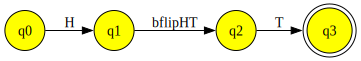

In [14]:
# Flips are biased

# Coin stays the same. The weighted version will have a higher probability of 3/16
bflipHHu =  hfst.regex('[H bflipHH H ]',definitions=defs)
bflipTTu =  hfst.regex('[T bflipTT T ]',definitions=defs)

# Coin changes, lower probability of 1/16
bflipHTu =  hfst.regex('[H bflipHT T ]',definitions=defs)
bflipTHu =  hfst.regex('[T bflipTH H ]',definitions=defs)

bflipHHu.determinize()
bflipTTu.determinize()   
bflipHTu.determinize()
bflipTHu.determinize()

bflipHTu.view()

In [15]:
# These name the 14 unweighted decorated events
eventdefs_u = { 
    "peekamyHHu":peekamyHHu,
    "peekamyTTu":peekamyTTu,
    "peekamyHTu":peekamyHTu,
    "peekamyTHu":peekamyTHu,
    "peekbobHHu":peekbobHHu,
    "peekbobTTu":peekbobTTu,
    "peekbobHTu":peekbobHTu,
    "peekbobTHu":peekbobTHu,
    "announceHHu":announceHHu,
    "announceTTu":announceTTu,
    "bflipHHu":bflipHHu,
    "bflipTTu":bflipTTu, 
    "bflipHTu":bflipHTu,
    "bflipTHu":bflipTHu }
defs.update(eventdefs_u)

### Assemble the set of unweighted events

In [16]:
EventPeekAmyU = hfst.regex('[peekamyHHu | peekamyTTu | peekamyHTu | peekamyTHu ]', definitions=defs)
EventPeekAmyU.determinize()

In [17]:
EventPeekBobU = hfst.regex('[peekbobHHu | peekbobTTu | peekbobHTu | peekbobTHu ]', definitions=defs)
EventPeekBobU.determinize()

In [18]:
EventFlipU = hfst.regex('[bflipHHu | bflipTTu | bflipHTu | bflipTHu ]', definitions=defs)
EventFlipU.determinize()

In [19]:
EventAnnounceU = hfst.regex('[announceHHu | announceTTu ]', definitions=defs)
EventAnnounceU.determinize()

In [20]:
defs.update({"EventPeekAmyU":EventPeekAmyU,"EventPeekBobU":EventPeekBobU,"EventFliUp":EventFlipU,"EventAnnounceU":EventAnnounceU})

In [21]:
EventU = EventPeekAmyU.copy()
EventU.disjunct(EventPeekBobU)
EventU.disjunct(EventFlipU)
EventU.disjunct(EventAnnounceU)
EventU.minimize()
defs.update({"EventU":EventU})

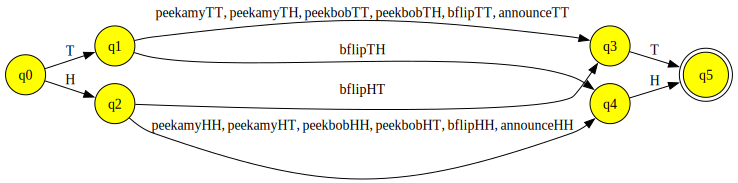

In [22]:
EventU.view()

In [151]:
# Test -- it should be 14
EventNameU = EventU.extract_paths().keys()
EventNameU = [x[1:-1] for x in EventNameU]
print(EventNameU)
print(len(EventNameU))

['announceHH', 'bflipHH', 'bflipHT', 'peekamyHH', 'peekamyHT', 'peekbobHH', 'peekbobHT', 'announceTT', 'bflipTH', 'bflipTT', 'peekamyTH', 'peekamyTT', 'peekbobTH', 'peekbobTT']
14


## Cn in KAT algebra
This is thought to work both for symbolic and probabilistic arguments.

In [169]:
# Delete the second state in a block of two states.  This is used defining Ekat concatenation.
Squash = hfst.regex('St -> 0 || St _', definitions = defs)
# Strings that do not contain an unequal state pair
Wf0 = hfst.regex('~[$ UnequalStPair]', definitions = defs)
defs.update({"Squash":Squash,"Wf0":Wf0})

In [170]:
# define Cn(X,Y) [[[X Y] & Wf0] .o. Squash].l;
def Cn(X,Y):
    Z = X.copy()
    Z.concatenate(Y)
    Z.intersect(Wf0)
    Z.compose(Squash)
    Z.output_project()
    #Z.determinize() or Z.minimize() or both? 
    Z.minimize()
    return Z

## Add weights to the events
### Weights of veridical peeks
They are 3/16, or 1.67 in the log space.

1.6739764335716716


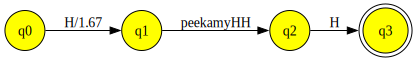

In [26]:
peekamyHH = Cn(peekamyHHu,Id_3_16)
print(-math.log(3/16))
peekamyHH.view()

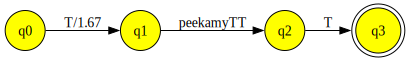

In [27]:
peekamyTT = Cn(peekamyTTu,Id_3_16)
peekamyTT.view()

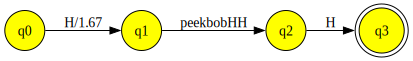

In [28]:
peekbobHH = Cn(peekbobHHu,Id_3_16)
peekbobHH.view()

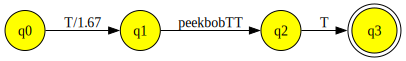

In [29]:
peekbobTT = Cn(peekbobTTu,Id_3_16)
peekbobTT.view()

In [30]:
defs.update({"peekamyHH":peekamyHH,"peekamyTT":peekamyTT,"peekbobHH":peekbobHH,"peekbobTT":peekbobTT})

### Weights of incorrect peeks
They are 1/16, or 2.77 in the log space.

Amy peeks at actual H, perceiving it as T

2.772588722239781


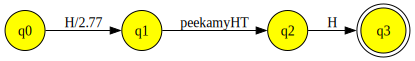

In [31]:
peekamyHT = Cn(peekamyHTu,Id_1_16)
print(-math.log(1/16))
peekamyHT.view()

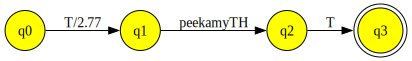

In [32]:
peekamyTH = Cn(peekamyTHu,Id_1_16)
peekamyTH.view()

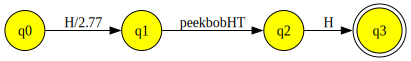

In [33]:
peekbobHT = Cn(peekbobHTu,Id_1_16)
peekbobHT.view()

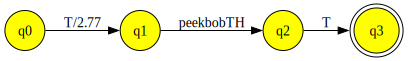

In [34]:
peekbobTH = Cn(peekbobTHu,Id_1_16)
peekbobTH.view()

In [35]:
defs.update({ 
    "peekamyHH":peekamyHH,
    "peekamyTT":peekamyTT,
    "peekamyHT":peekamyHT,
    "peekamyTH":peekamyTH })
defs.update({ 
    "peekbobHH":peekbobHH,
    "peekbobTT":peekbobTT,
    "peekbobHT":peekbobHT,
    "peekbobTH":peekbobTH })

## Weights of flips

In [36]:
# Stays same, weight 3/16
bflipHH = Cn(bflipHHu,Id_3_16)
bflipTT = Cn(bflipTTu,Id_3_16)
# Changes, weight 1/16
bflipHT = Cn(bflipHTu,Id_1_16)
bflipTH = Cn(bflipTHu,Id_1_16)

defs.update({"bflipHH":bflipHH,"bflipTT":bflipTT})

## Weights of announcements
They have weight 1/4, or 4/16.

1.3862943611198906


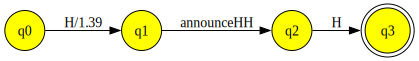

In [37]:
announceHH = Cn(announceHHu,Id_4_16)
print(-math.log(4/16))
announceHH.view()

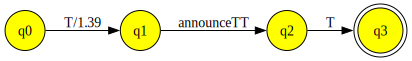

In [38]:
announceTT = Cn(announceTTu,Id_4_16)
defs.update({"announceHH":announceHH,"announceTT":announceTT})
announceTT.view()

## Set of decorated events and subsets thereof
Assemble this directly with HFST operations. We have indication that the defs
mechanism strips off weights.

In [39]:
# Bare event names
eventName = [s[1:-1] for s in EventU.extract_paths().keys()]
eventName


['announceHH',
 'bflipHH',
 'bflipHT',
 'peekamyHH',
 'peekamyHT',
 'peekbobHH',
 'peekbobHT',
 'announceTT',
 'bflipTH',
 'bflipTT',
 'peekamyTH',
 'peekamyTT',
 'peekbobTH',
 'peekbobTT']

In [40]:
# Write the code to assemble hEvent with HFST methods
for n in eventName: print(f'hEvent.disjunct({n})')

hEvent.disjunct(announceHH)
hEvent.disjunct(bflipHH)
hEvent.disjunct(bflipHT)
hEvent.disjunct(peekamyHH)
hEvent.disjunct(peekamyHT)
hEvent.disjunct(peekbobHH)
hEvent.disjunct(peekbobHT)
hEvent.disjunct(announceTT)
hEvent.disjunct(bflipTH)
hEvent.disjunct(bflipTT)
hEvent.disjunct(peekamyTH)
hEvent.disjunct(peekamyTT)
hEvent.disjunct(peekbobTH)
hEvent.disjunct(peekbobTT)


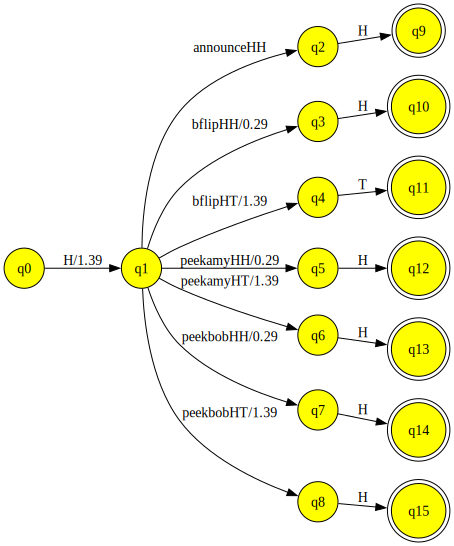

In [41]:
hEvent = announceHH.copy()
hEvent.disjunct(bflipHH)
hEvent.disjunct(bflipHT)
hEvent.disjunct(peekamyHH)
hEvent.disjunct(peekamyHT)
hEvent.disjunct(peekbobHH)
hEvent.disjunct(peekbobHT)
hEvent.determinize()
defs.update({"hEvent":hEvent})
hEvent.view()

In [42]:
# Write the code to assemble hEvent with HFST methods
# Use the last seven.
for n in eventName: print(f'tEvent.disjunct({n})')

tEvent.disjunct(announceHH)
tEvent.disjunct(bflipHH)
tEvent.disjunct(bflipHT)
tEvent.disjunct(peekamyHH)
tEvent.disjunct(peekamyHT)
tEvent.disjunct(peekbobHH)
tEvent.disjunct(peekbobHT)
tEvent.disjunct(announceTT)
tEvent.disjunct(bflipTH)
tEvent.disjunct(bflipTT)
tEvent.disjunct(peekamyTH)
tEvent.disjunct(peekamyTT)
tEvent.disjunct(peekbobTH)
tEvent.disjunct(peekbobTT)


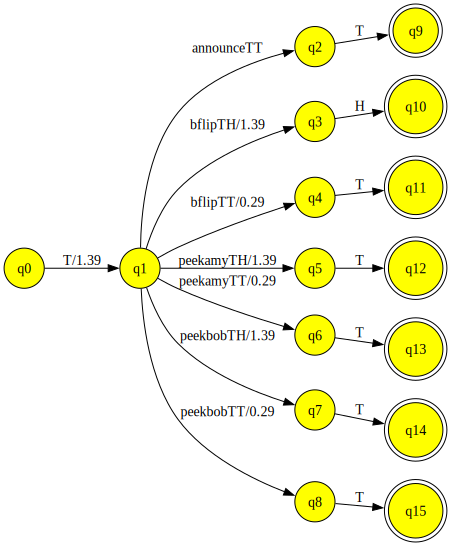

In [43]:
tEvent = announceTT.copy()
tEvent.disjunct(bflipTH)
tEvent.disjunct(bflipTT)
tEvent.disjunct(peekamyTH)
tEvent.disjunct(peekamyTT)
tEvent.disjunct(peekbobTH)
tEvent.disjunct(peekbobTT)
tEvent.determinize()
defs.update({"tEvent":tEvent})
tEvent.view()

## Set of weighted events

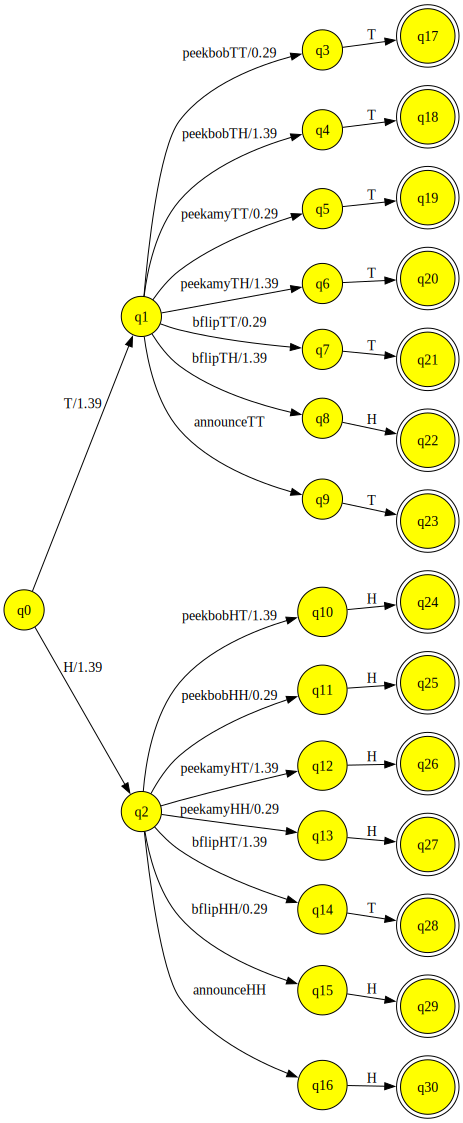

In [44]:
Event = hEvent.copy()
Event.disjunct(tEvent)
defs.update({"Event":Event})
Event.determinize()
Event.view()

## Worlds of a given length

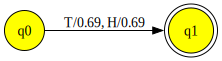

In [45]:
# Initial worlds, each with probability 1/2
W0 = weighted_id(1,2)
W0.view()

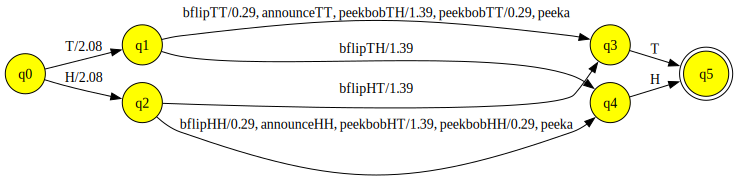

In [46]:
W1 = Cn(W0,Event)
W1.view()

In [47]:
# help(W1.extract_paths)
W1.extract_paths(output='raw')

((2.0794410705566406, (('H', 'H'), ('announceHH', 'announceHH'), ('H', 'H'))),
 (2.0794410705566406, (('T', 'T'), ('announceTT', 'announceTT'), ('T', 'T'))),
 (2.3675270080566406, (('H', 'H'), ('bflipHH', 'bflipHH'), ('H', 'H'))),
 (2.3675270080566406, (('H', 'H'), ('peekamyHH', 'peekamyHH'), ('H', 'H'))),
 (2.3675270080566406, (('H', 'H'), ('peekbobHH', 'peekbobHH'), ('H', 'H'))),
 (2.3675270080566406, (('T', 'T'), ('bflipTT', 'bflipTT'), ('T', 'T'))),
 (2.3675270080566406, (('T', 'T'), ('peekamyTT', 'peekamyTT'), ('T', 'T'))),
 (2.3675270080566406, (('T', 'T'), ('peekbobTT', 'peekbobTT'), ('T', 'T'))),
 (3.4661600589752197, (('H', 'H'), ('bflipHT', 'bflipHT'), ('T', 'T'))),
 (3.4661600589752197, (('H', 'H'), ('peekamyHT', 'peekamyHT'), ('H', 'H'))),
 (3.4661600589752197, (('H', 'H'), ('peekbobHT', 'peekbobHT'), ('H', 'H'))),
 (3.4661600589752197, (('T', 'T'), ('bflipTH', 'bflipTH'), ('H', 'H'))),
 (3.4661600589752197, (('T', 'T'), ('peekamyTH', 'peekamyTH'), ('T', 'T'))),
 (3.4661600

In [48]:
W2 = Cn(W1,Event)
W3 = Cn(W2,Event)
W4 = Cn(W3,Event)
W5 = Cn(W4,Event)
W6 = Cn(W5,Event)

## Sum weights

In [49]:
W1.extract_paths(output='raw')

((2.0794410705566406, (('H', 'H'), ('announceHH', 'announceHH'), ('H', 'H'))),
 (2.0794410705566406, (('T', 'T'), ('announceTT', 'announceTT'), ('T', 'T'))),
 (2.3675270080566406, (('H', 'H'), ('bflipHH', 'bflipHH'), ('H', 'H'))),
 (2.3675270080566406, (('H', 'H'), ('peekamyHH', 'peekamyHH'), ('H', 'H'))),
 (2.3675270080566406, (('H', 'H'), ('peekbobHH', 'peekbobHH'), ('H', 'H'))),
 (2.3675270080566406, (('T', 'T'), ('bflipTT', 'bflipTT'), ('T', 'T'))),
 (2.3675270080566406, (('T', 'T'), ('peekamyTT', 'peekamyTT'), ('T', 'T'))),
 (2.3675270080566406, (('T', 'T'), ('peekbobTT', 'peekbobTT'), ('T', 'T'))),
 (3.4661600589752197, (('H', 'H'), ('bflipHT', 'bflipHT'), ('T', 'T'))),
 (3.4661600589752197, (('H', 'H'), ('peekamyHT', 'peekamyHT'), ('H', 'H'))),
 (3.4661600589752197, (('H', 'H'), ('peekbobHT', 'peekbobHT'), ('H', 'H'))),
 (3.4661600589752197, (('T', 'T'), ('bflipTH', 'bflipTH'), ('H', 'H'))),
 (3.4661600589752197, (('T', 'T'), ('peekamyTH', 'peekamyTH'), ('T', 'T'))),
 (3.4661600

In [50]:
# This is naive, there should be a better alternative using the forward algorithm.
def total_weight(M):
    total = 0.0
    for weight, path in M.extract_paths(output='raw'):
        total += math.exp(-weight)
    return(total)

In [51]:
print(f'{total_weight(W0)} {len(W0.extract_paths())}')
print(f'{total_weight(W1)} {len(W1.extract_paths())}')
print(f'{total_weight(W2)} {len(W2.extract_paths())}')
print(f'{total_weight(W3)} {len(W3.extract_paths())}')
print(f'{total_weight(W4)} {len(W4.extract_paths())}')
print(f'{total_weight(W5)} {len(W5.extract_paths())}')
print(f'{total_weight(W6)} {len(W6.extract_paths())}')

1.0000001769092957 2
0.999693742039849 14
0.9993875071850402 98
0.9990816452499552 686
0.9987752388357302 4802
0.9984689320950879 33614
0.9981627078921873 235298


## Event alternatives

In [52]:
# Unconstrained cross product of the decorated unweighted events
# This is used in defining event alternative relations.
eventCrossEventU = EventU.copy()
eventCrossEventU.cross_product(EventU)

defs.update({"eventCrossEventU": eventCrossEventU})
# Shorter name
defs.update({"eCe": eventCrossEventU})


In [53]:
def crossRel(upper,lower):
    U = hfst.regex('a & b')
    for m in upper: U.disjunct(m)
    L = hfst.regex('a & b')
    for m in lower: L.disjunct(m)
    U.cross_product(L)
    U.determinize()
    return(U)


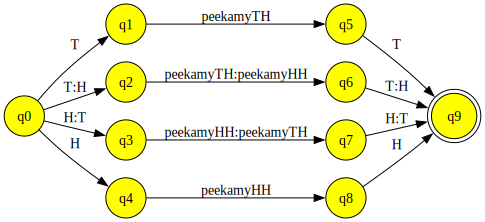

In [54]:
X = crossRel([peekamyHHu,peekamyTHu],[peekamyHHu,peekamyTHu])
X.view()

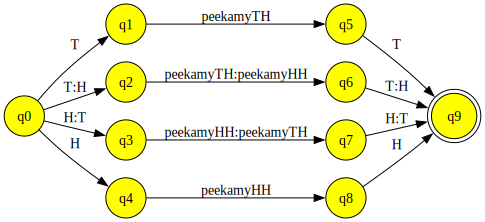

In [55]:
# Amy's alternatives for Amy's own peeks
Xh = crossRel([peekamyHHu,peekamyTHu],[peekamyHHu,peekamyTHu])
Xt = crossRel([peekamyHTu,peekamyTTu],[peekamyHTu,peekamyTTu])
Xh.view()

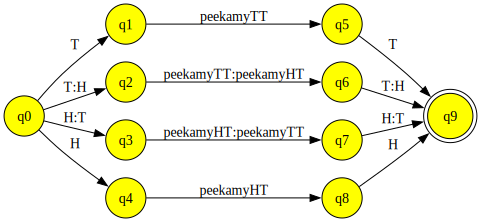

In [56]:
Xt.view()

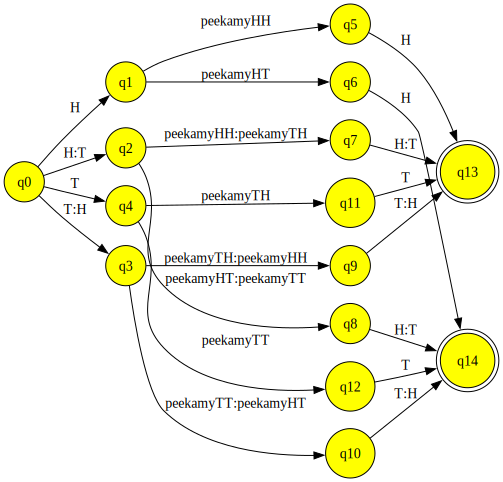

In [57]:
amyAmyPeekEventRel = Xh.copy()
amyAmyPeekEventRel.disjunct(Xt)
amyAmyPeekEventRel.determinize()
amyAmyPeekEventRel.view()

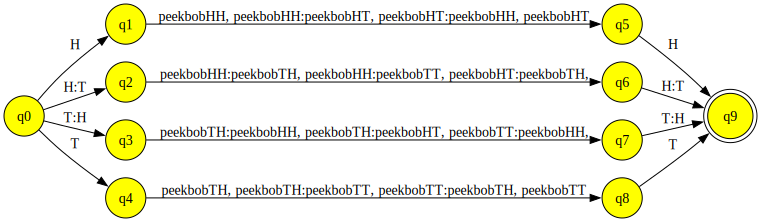

In [58]:
# Amy's alternatives for Bob's peeks
# is a product of four events on each side, she just knows Bob is peeking.
X = [peekbobHHu,peekbobHTu,peekbobTHu,peekbobTTu]
amyBobPeekEventRel = crossRel(X,X)
amyBobPeekEventRel.determinize()
amyBobPeekEventRel.view()

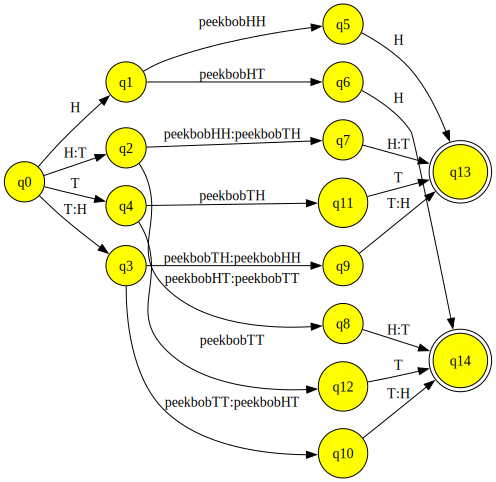

In [59]:
# Bob's alternatives for Bob's peeks
# Bob sensing H
X = [peekbobHHu,peekbobTHu]
bobBobPeekEventRel = crossRel(X,X)
# Bob sensing T
X = [peekbobHTu,peekbobTTu]
bobBobPeekEventRel.disjunct(crossRel(X,X))
bobBobPeekEventRel.determinize()
bobBobPeekEventRel.view()

4


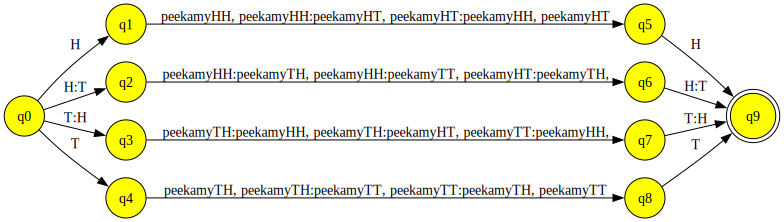

In [63]:
# Bob's alternatives for Amy's peeks
# is a product of four events on each side, she just knows Bob is peeking.
X = [peekamyHHu,peekamyHTu,peekamyTHu,peekamyTTu]
bobAmyPeekEventRel = crossRel(X,X)
bobAmyPeekEventRel.determinize()
bobAmyPeekEventRel.view()

In [128]:
# Assemble alternative relation on peeks
amyPeekRel = amyAmyPeekEventRel.copy()
amyPeekRel.disjunct(amyBobPeekEventRel)

bobPeekRel = bobBobPeekEventRel.copy()
bobPeekRel.disjunct(bobAmyPeekEventRel)

### Alternative relations for flips
Agents have no constraints

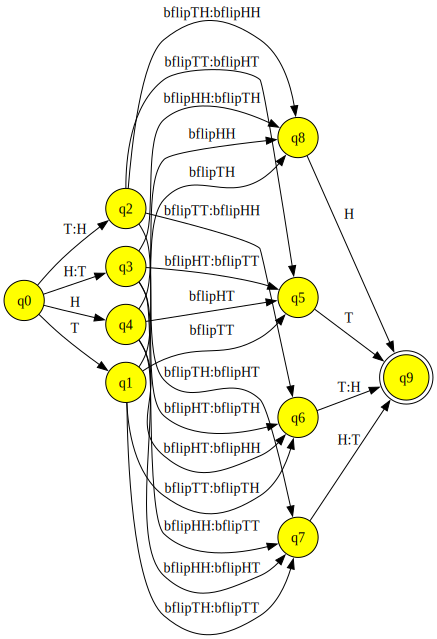

In [129]:
X = [bflipHHu,bflipHTu,bflipTHu,bflipTTu]
amyFlipRel = crossRel(X,X)
bobFlipRel = crossRel(X,X)
amyFlipRel.view()

### Alternative relations for announcements

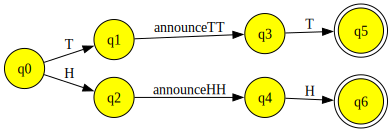

In [130]:
amyAnnounceRel = announceHHu.copy()
amyAnnounceRel.disjunct(announceTTu)
amyAnnounceRel.determinize()
amyAnnounceRel.view()

In [131]:
bobAnnounceRel = amyAnnounceRel.copy()

### Assemble decorated event alternative relations

In [132]:
amyEventRel = amyPeekRel.copy()
amyEventRel.disjunct(amyFlipRel)
amyEventRel.disjunct(amyAnnounceRel)
amyEventRel.determinize()

In [133]:
bobEventRel = bobPeekRel.copy()
bobEventRel.disjunct(bobFlipRel)
bobEventRel.disjunct(bobAnnounceRel)
bobEventRel.determinize()

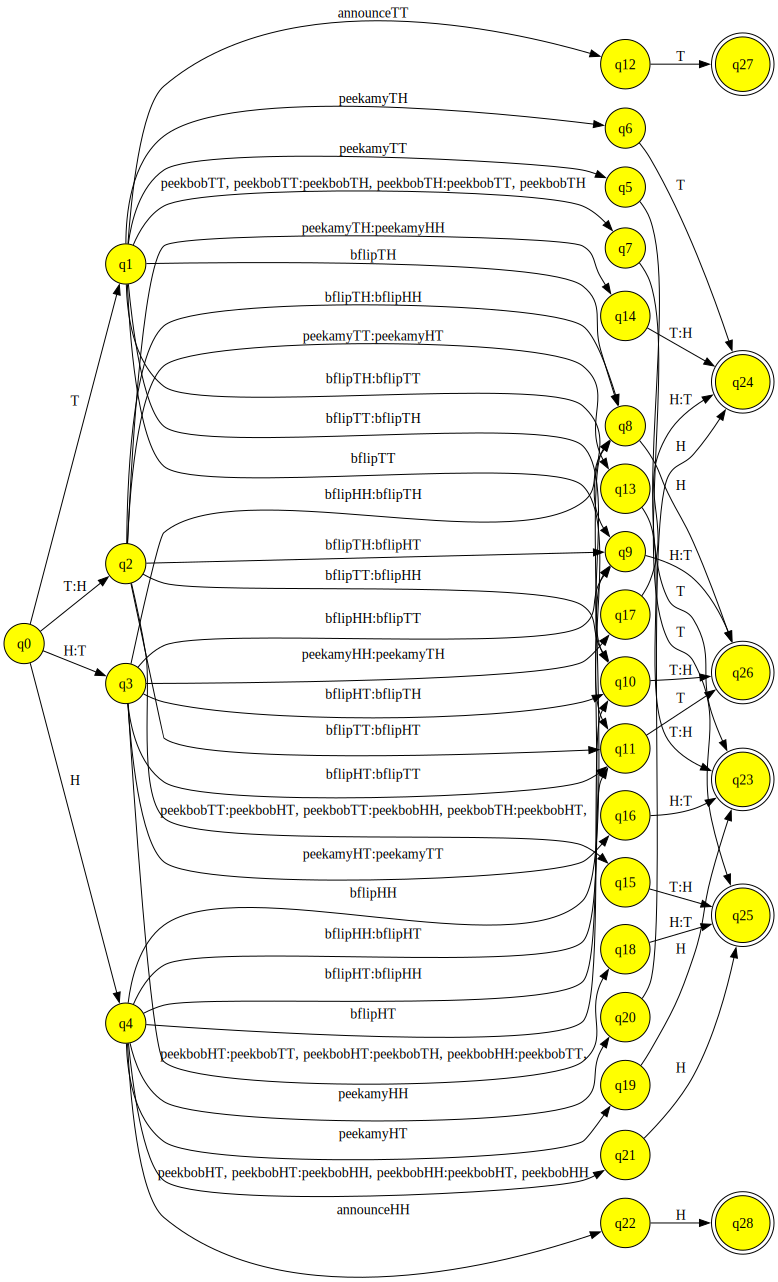

In [134]:
amyEventRel.view()

## Test the event relations
For each agent and the 14 events, display the decorated event alternatives
as an acceptor.

In [176]:
def amyEventImage(e):
    result = e.copy()
    result.compose(amyEventRel)
    result.output_project()
    return(result)
# NB the argument should be unweighted for this test

def bobEventImage(e):
    result = e.copy()
    result.compose(bobEventRel)
    result.output_project()
    return(result)

1. Amy's alternatives to announceHHu


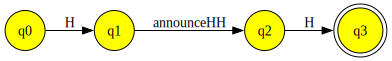

2. Amy's alternatives to announceTTu


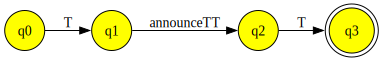

3. Amy's alternatives to bflipHHu


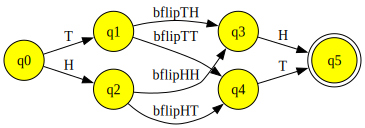

4. Amy's alternatives to bflipHTu


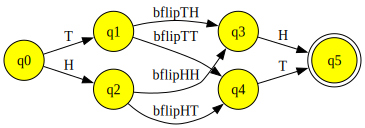

5. Amy's alternatives to bflipTHu


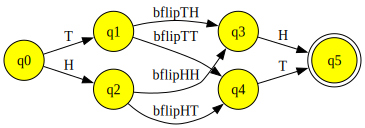

6. Amy's alternatives to bflipTTu


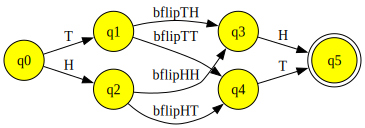

7. Amy's alternatives to peekamyHHu


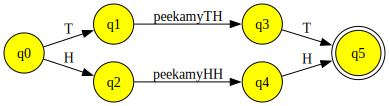

8. Amy's alternatives to peekamyHTu


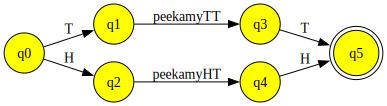

9. Amy's alternatives to peekamyTHu


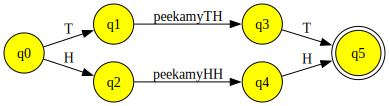

10. Amy's alternatives to peekamyTTu


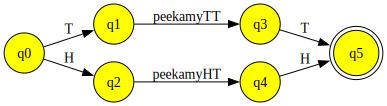

11. Amy's alternatives to peekbobHHu


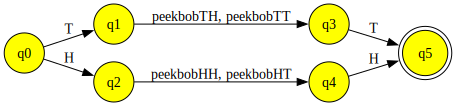

12. Amy's alternatives to peekbobHTu


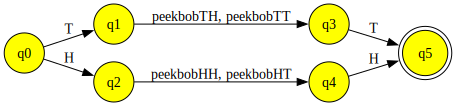

13. Amy's alternatives to peekbobTHu


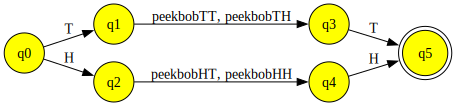

14. Amy's alternatives to peekbobTTu


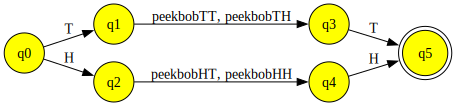

In [177]:
k = 1
for ename in EventNameU:
    ename = ename + "u"
    e = eval(ename)
    image = amyEventImage(e)
    print(f'{k}. Amy\'s alternatives to {ename}')
    display(image.view())
    k = k + 1

1. Bob's alternatives to announceHHu


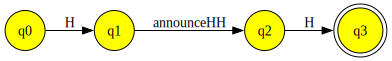

2. Bob's alternatives to announceTTu


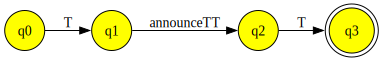

3. Bob's alternatives to bflipHHu


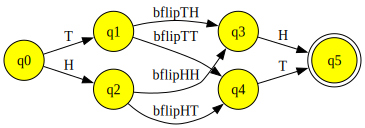

4. Bob's alternatives to bflipHTu


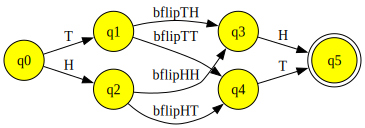

5. Bob's alternatives to bflipTHu


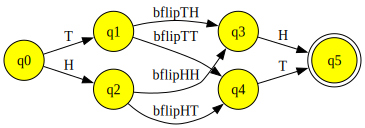

6. Bob's alternatives to bflipTTu


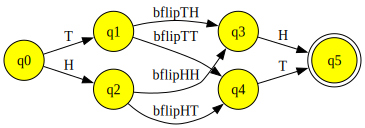

7. Bob's alternatives to peekamyHHu


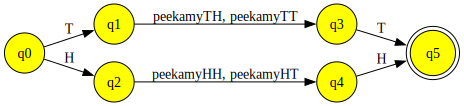

8. Bob's alternatives to peekamyHTu


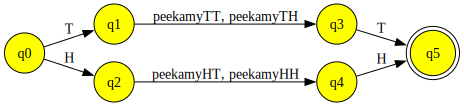

9. Bob's alternatives to peekamyTHu


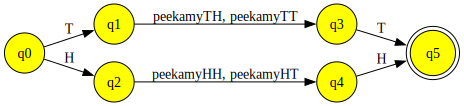

10. Bob's alternatives to peekamyTTu


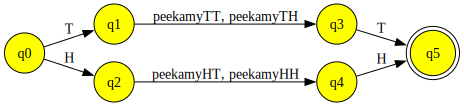

11. Bob's alternatives to peekbobHHu


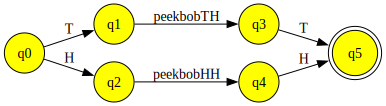

12. Bob's alternatives to peekbobHTu


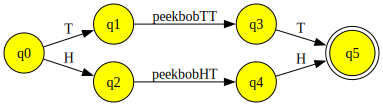

13. Bob's alternatives to peekbobTHu


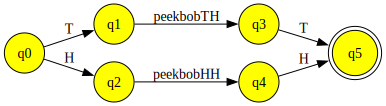

14. Bob's alternatives to peekbobTTu


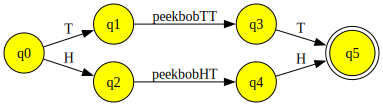

In [178]:
k = 1
for ename in EventNameU:
    ename = ename + "u"
    e = eval(ename)
    image = bobEventImage(e)
    print(f'{k}. Bob\'s alternatives to {ename}')
    display(image.view())
    k = k + 1

The above looks good.
## Epik operations
These are defined using HFST methods.
Product Cn was defined above.

In [164]:
# define Kpl(X) [[[X+] & Wf0] .o. Squash].l;
def Kpl(X):
    Z = X.copy()
    Z.repeat_plus()
    Z.intersect(Wf0)
    Z.compose(Squash)
    Z.output_project()
    Z.determinize()
    # Z.minimize()
    return Z

In [166]:
# Kleene Star
# The identity is St, not the empty string.
# define Kst(X) St |  Kpl(X);
# Here the identity is Id.
def Kst(X):
    Z = Kpl(X)
    Z.disjunct(Id)
    Z.determinize()
    # Z.minimize()
    return(Z)

In [167]:
# Inverse of Squash
Squashi = Squash.copy()
Squashi.invert()

Wf0 was defined in the section defining Cn.

In [171]:
# Concatenation product of relations
# NB this in not relation composition.
# define Cnr(R,S) Squash.i .o. Wf0 .o. [R S] .o. Wf0 .o. Squash;
def Cnr(R,S):
    Z = R.copy()
    Z.concatenate(S)
    Z.compose(Wf0)
    Z.compose(Squash)
    Z.invert()
    Z.compose(Wf0)
    Z.compose(Squash)
    Z.invert()
    Z.determinize()
    return(Z)

In [173]:
# Kleene plus on relations
# define RelKpl(X) Squash.i .o. Wf0 .o. [X+] .o. Wf0 .o. Squash;
def RelKpl(R):
    Z = R.copy()
    Z.repeat_plus() 
    Z.compose(Wf0)
    Z.compose(Squash)
    Z.invert()
    Z.compose(Wf0)
    Z.compose(Squash)
    Z.invert()
    Z.determinize()
    return(Z)

In [174]:
# Kleene star on relations
# This is used in defining world alternative relations.
# The total relation on St is included.
# define RelKst(X) [St .x. St] | RelKpl(X);
def RelKst(R):
    Z = RelKpl(R)
    IdxId = Id.copy()
    IdxId.cross_product(St)
    Z.disjunct(IdxId)
    return(Z)

## Unweighted world alterative relations
Unweighted Amy world alternative relation.

In [182]:
# Amy world alternative relation. 
amyU = RelKst(amyEventRel)
def amyImage(w):
    result = w.copy()
    result.compose(amyU)
    result.output_project()
    return(result)

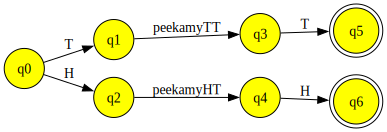

In [186]:
amyImage(peekamyTTu).view()

1. Amy's alternatives to announceHHu announceHHu


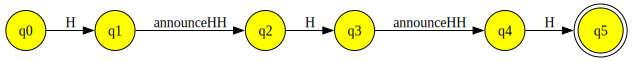

2. Amy's alternatives to announceHHu announceTTu


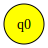

3. Amy's alternatives to announceHHu bflipHHu


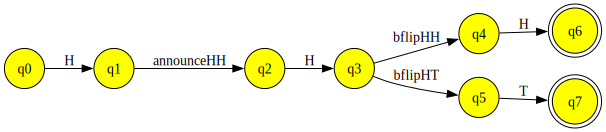

4. Amy's alternatives to announceHHu bflipHTu


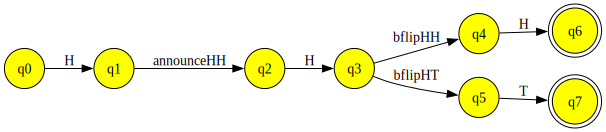

5. Amy's alternatives to announceHHu bflipTHu


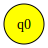

6. Amy's alternatives to announceHHu bflipTTu


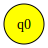

7. Amy's alternatives to announceHHu peekamyHHu


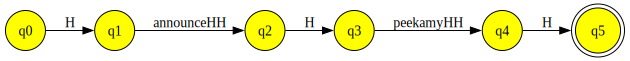

8. Amy's alternatives to announceHHu peekamyHTu


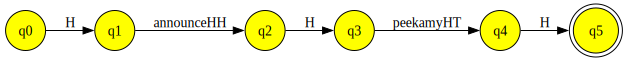

9. Amy's alternatives to announceHHu peekamyTHu


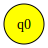

10. Amy's alternatives to announceHHu peekamyTTu


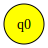

11. Amy's alternatives to announceHHu peekbobHHu


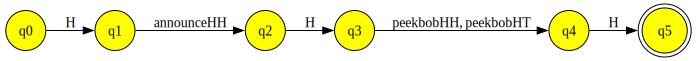

12. Amy's alternatives to announceHHu peekbobHTu


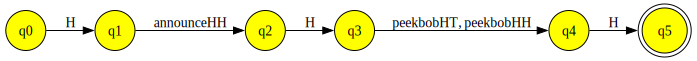

13. Amy's alternatives to announceHHu peekbobTHu


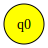

14. Amy's alternatives to announceHHu peekbobTTu


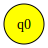

15. Amy's alternatives to announceTTu announceHHu


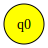

16. Amy's alternatives to announceTTu announceTTu


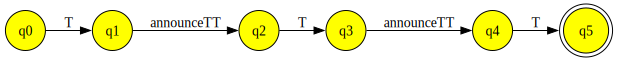

17. Amy's alternatives to announceTTu bflipHHu


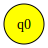

18. Amy's alternatives to announceTTu bflipHTu


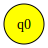

19. Amy's alternatives to announceTTu bflipTHu


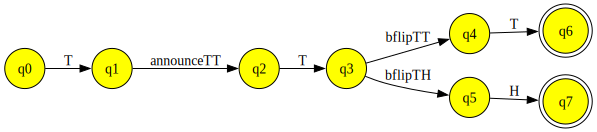

20. Amy's alternatives to announceTTu bflipTTu


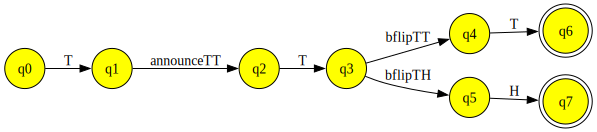

21. Amy's alternatives to announceTTu peekamyHHu


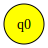

22. Amy's alternatives to announceTTu peekamyHTu


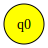

23. Amy's alternatives to announceTTu peekamyTHu


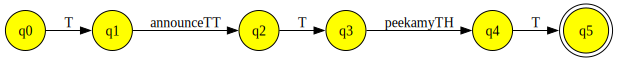

24. Amy's alternatives to announceTTu peekamyTTu


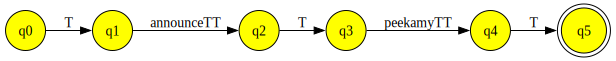

25. Amy's alternatives to announceTTu peekbobHHu


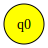

26. Amy's alternatives to announceTTu peekbobHTu


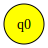

27. Amy's alternatives to announceTTu peekbobTHu


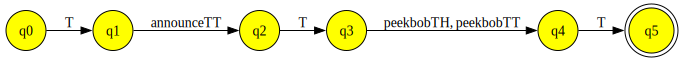

28. Amy's alternatives to announceTTu peekbobTTu


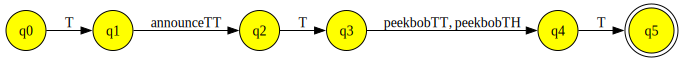

29. Amy's alternatives to bflipHHu announceHHu


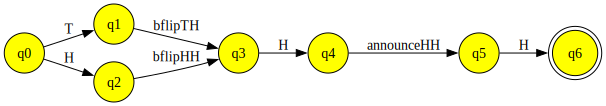

30. Amy's alternatives to bflipHHu announceTTu


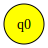

31. Amy's alternatives to bflipHHu bflipHHu


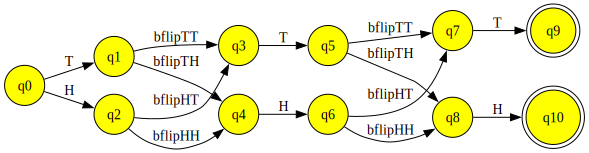

32. Amy's alternatives to bflipHHu bflipHTu


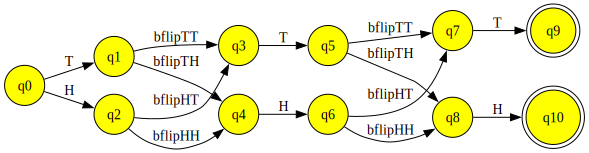

33. Amy's alternatives to bflipHHu bflipTHu


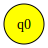

34. Amy's alternatives to bflipHHu bflipTTu


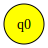

35. Amy's alternatives to bflipHHu peekamyHHu


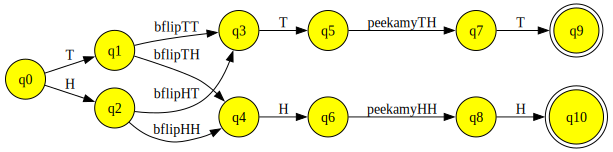

36. Amy's alternatives to bflipHHu peekamyHTu


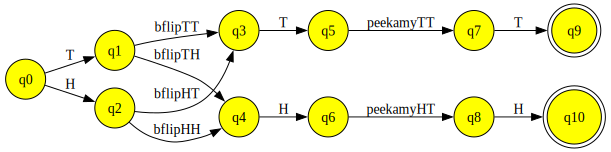

37. Amy's alternatives to bflipHHu peekamyTHu


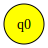

38. Amy's alternatives to bflipHHu peekamyTTu


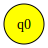

39. Amy's alternatives to bflipHHu peekbobHHu


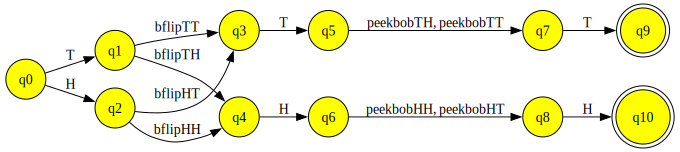

40. Amy's alternatives to bflipHHu peekbobHTu


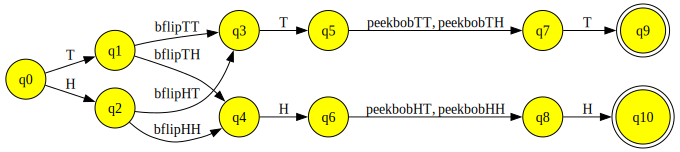

41. Amy's alternatives to bflipHHu peekbobTHu


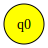

42. Amy's alternatives to bflipHHu peekbobTTu


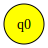

43. Amy's alternatives to bflipHTu announceHHu


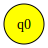

44. Amy's alternatives to bflipHTu announceTTu


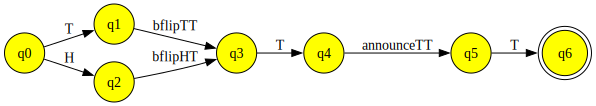

45. Amy's alternatives to bflipHTu bflipHHu


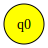

46. Amy's alternatives to bflipHTu bflipHTu


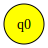

47. Amy's alternatives to bflipHTu bflipTHu


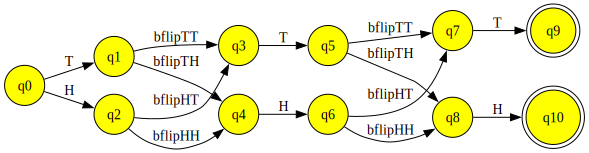

48. Amy's alternatives to bflipHTu bflipTTu


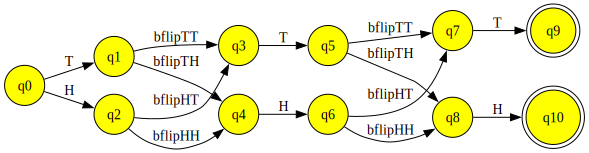

49. Amy's alternatives to bflipHTu peekamyHHu


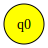

50. Amy's alternatives to bflipHTu peekamyHTu


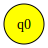

51. Amy's alternatives to bflipHTu peekamyTHu


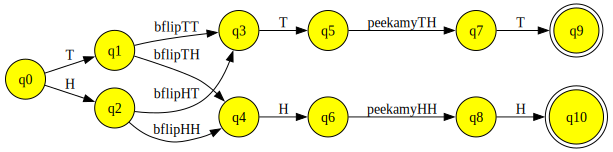

52. Amy's alternatives to bflipHTu peekamyTTu


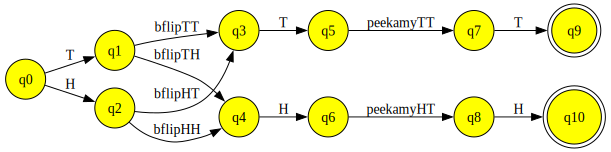

53. Amy's alternatives to bflipHTu peekbobHHu


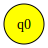

54. Amy's alternatives to bflipHTu peekbobHTu


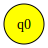

55. Amy's alternatives to bflipHTu peekbobTHu


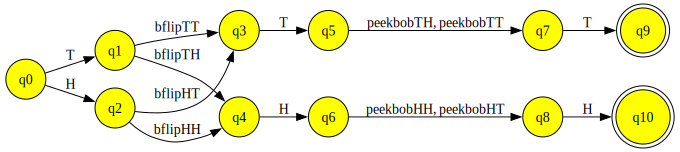

56. Amy's alternatives to bflipHTu peekbobTTu


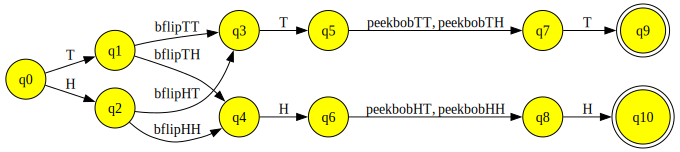

57. Amy's alternatives to bflipTHu announceHHu


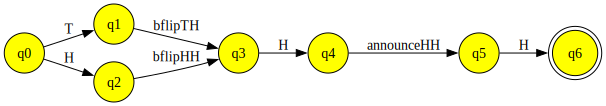

58. Amy's alternatives to bflipTHu announceTTu


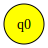

59. Amy's alternatives to bflipTHu bflipHHu


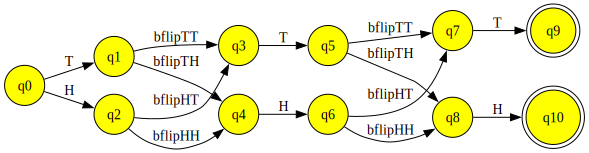

60. Amy's alternatives to bflipTHu bflipHTu


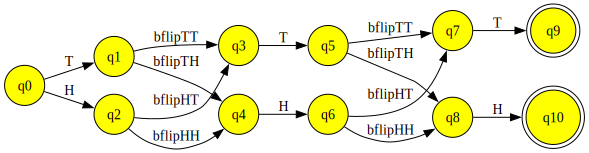

61. Amy's alternatives to bflipTHu bflipTHu


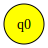

62. Amy's alternatives to bflipTHu bflipTTu


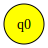

63. Amy's alternatives to bflipTHu peekamyHHu


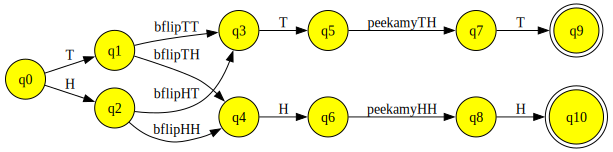

64. Amy's alternatives to bflipTHu peekamyHTu


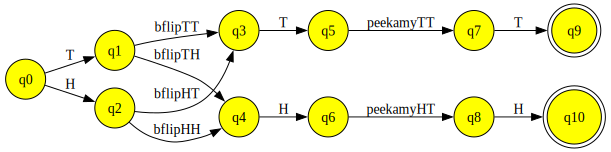

65. Amy's alternatives to bflipTHu peekamyTHu


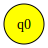

66. Amy's alternatives to bflipTHu peekamyTTu


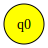

67. Amy's alternatives to bflipTHu peekbobHHu


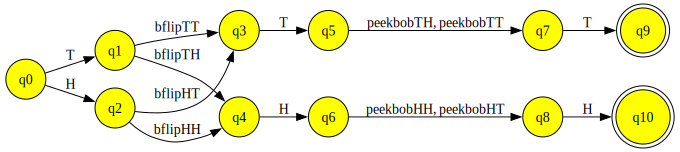

68. Amy's alternatives to bflipTHu peekbobHTu


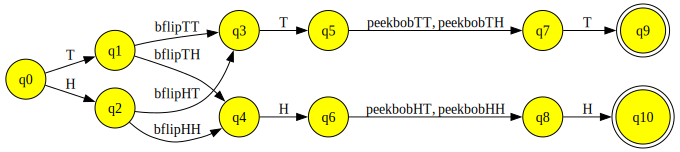

69. Amy's alternatives to bflipTHu peekbobTHu


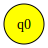

70. Amy's alternatives to bflipTHu peekbobTTu


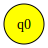

71. Amy's alternatives to bflipTTu announceHHu


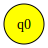

72. Amy's alternatives to bflipTTu announceTTu


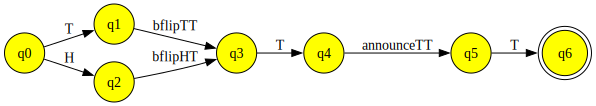

73. Amy's alternatives to bflipTTu bflipHHu


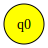

74. Amy's alternatives to bflipTTu bflipHTu


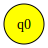

75. Amy's alternatives to bflipTTu bflipTHu


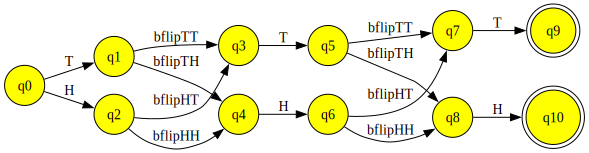

76. Amy's alternatives to bflipTTu bflipTTu


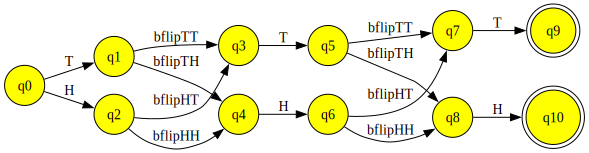

77. Amy's alternatives to bflipTTu peekamyHHu


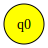

78. Amy's alternatives to bflipTTu peekamyHTu


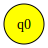

79. Amy's alternatives to bflipTTu peekamyTHu


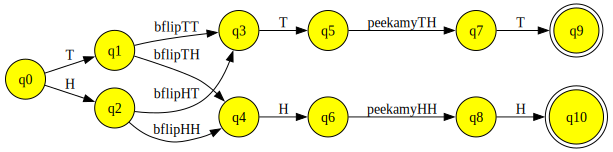

80. Amy's alternatives to bflipTTu peekamyTTu


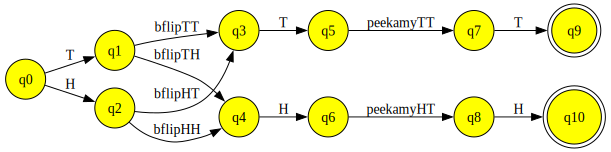

81. Amy's alternatives to bflipTTu peekbobHHu


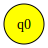

82. Amy's alternatives to bflipTTu peekbobHTu


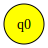

83. Amy's alternatives to bflipTTu peekbobTHu


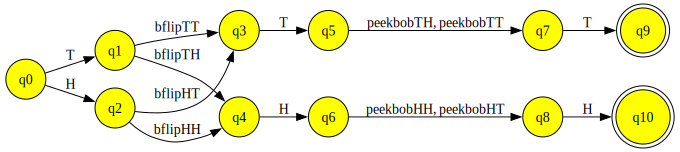

84. Amy's alternatives to bflipTTu peekbobTTu


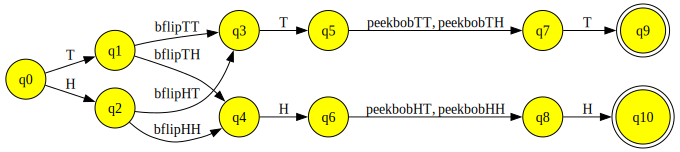

85. Amy's alternatives to peekamyHHu announceHHu


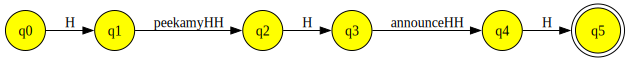

86. Amy's alternatives to peekamyHHu announceTTu


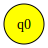

87. Amy's alternatives to peekamyHHu bflipHHu


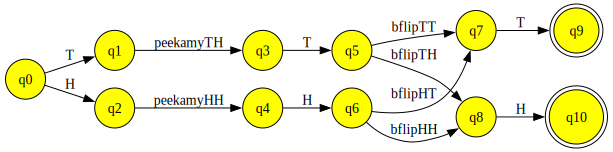

88. Amy's alternatives to peekamyHHu bflipHTu


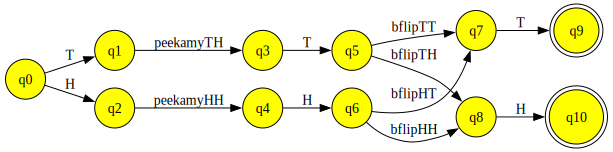

89. Amy's alternatives to peekamyHHu bflipTHu


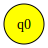

90. Amy's alternatives to peekamyHHu bflipTTu


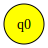

91. Amy's alternatives to peekamyHHu peekamyHHu


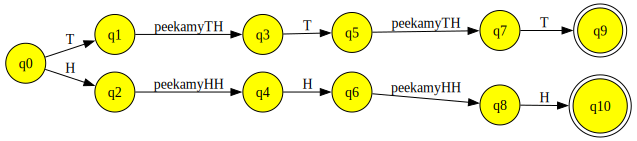

92. Amy's alternatives to peekamyHHu peekamyHTu


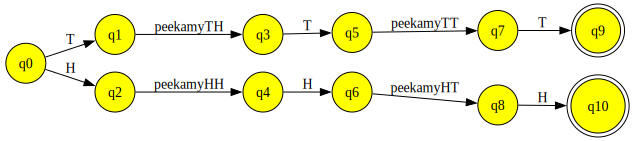

93. Amy's alternatives to peekamyHHu peekamyTHu


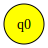

94. Amy's alternatives to peekamyHHu peekamyTTu


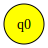

95. Amy's alternatives to peekamyHHu peekbobHHu


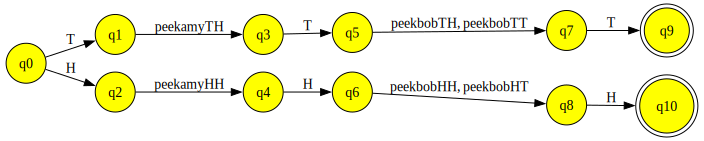

96. Amy's alternatives to peekamyHHu peekbobHTu


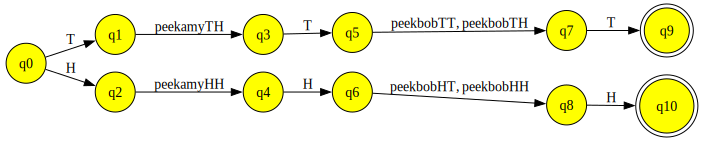

97. Amy's alternatives to peekamyHHu peekbobTHu


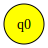

98. Amy's alternatives to peekamyHHu peekbobTTu


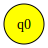

99. Amy's alternatives to peekamyHTu announceHHu


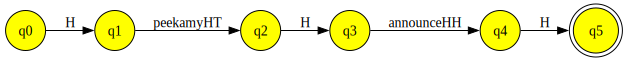

100. Amy's alternatives to peekamyHTu announceTTu


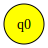

101. Amy's alternatives to peekamyHTu bflipHHu


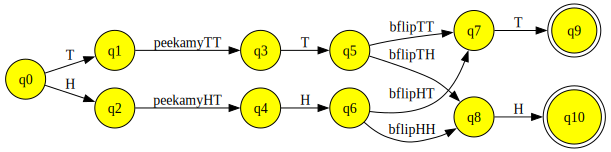

102. Amy's alternatives to peekamyHTu bflipHTu


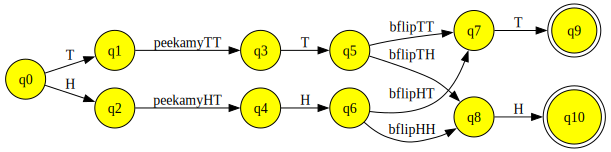

103. Amy's alternatives to peekamyHTu bflipTHu


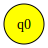

104. Amy's alternatives to peekamyHTu bflipTTu


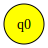

105. Amy's alternatives to peekamyHTu peekamyHHu


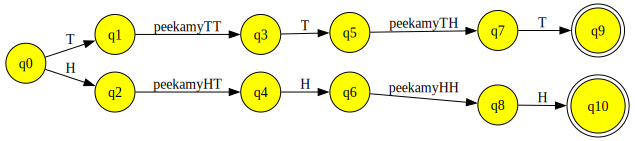

106. Amy's alternatives to peekamyHTu peekamyHTu


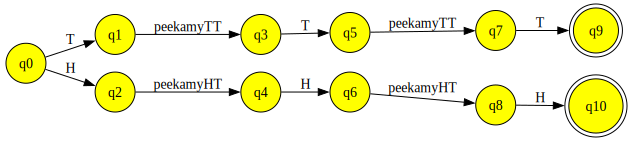

107. Amy's alternatives to peekamyHTu peekamyTHu


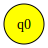

108. Amy's alternatives to peekamyHTu peekamyTTu


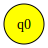

109. Amy's alternatives to peekamyHTu peekbobHHu


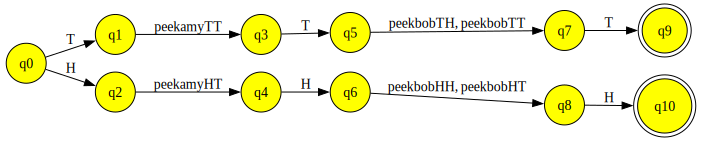

110. Amy's alternatives to peekamyHTu peekbobHTu


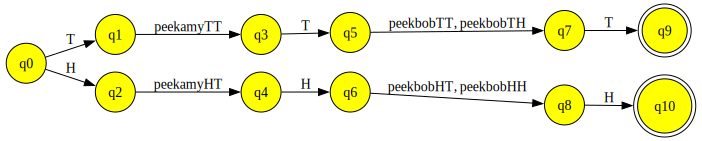

111. Amy's alternatives to peekamyHTu peekbobTHu


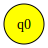

112. Amy's alternatives to peekamyHTu peekbobTTu


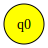

113. Amy's alternatives to peekamyTHu announceHHu


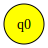

114. Amy's alternatives to peekamyTHu announceTTu


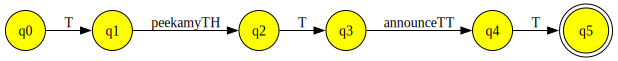

115. Amy's alternatives to peekamyTHu bflipHHu


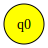

116. Amy's alternatives to peekamyTHu bflipHTu


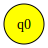

117. Amy's alternatives to peekamyTHu bflipTHu


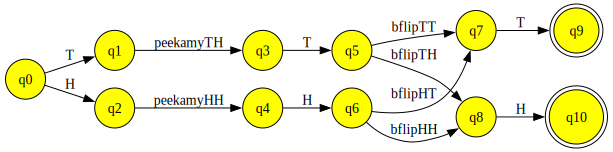

118. Amy's alternatives to peekamyTHu bflipTTu


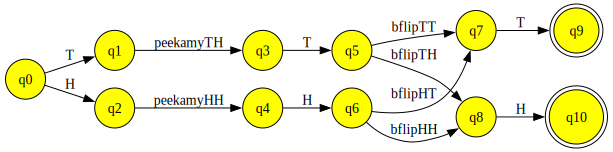

119. Amy's alternatives to peekamyTHu peekamyHHu


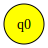

120. Amy's alternatives to peekamyTHu peekamyHTu


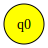

121. Amy's alternatives to peekamyTHu peekamyTHu


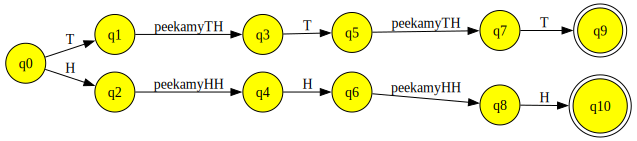

122. Amy's alternatives to peekamyTHu peekamyTTu


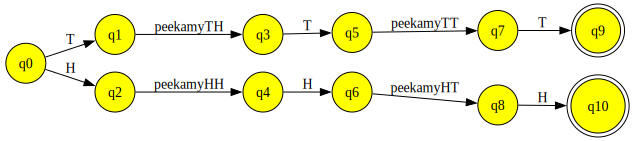

123. Amy's alternatives to peekamyTHu peekbobHHu


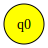

124. Amy's alternatives to peekamyTHu peekbobHTu


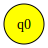

125. Amy's alternatives to peekamyTHu peekbobTHu


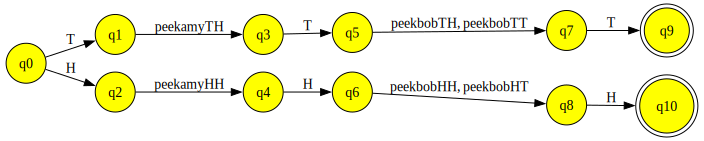

126. Amy's alternatives to peekamyTHu peekbobTTu


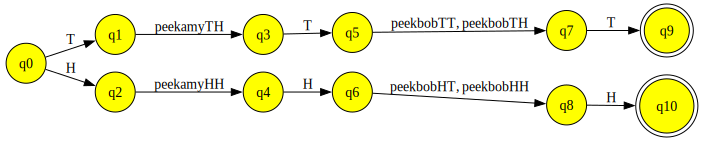

127. Amy's alternatives to peekamyTTu announceHHu


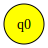

128. Amy's alternatives to peekamyTTu announceTTu


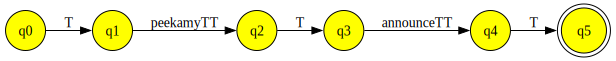

129. Amy's alternatives to peekamyTTu bflipHHu


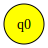

130. Amy's alternatives to peekamyTTu bflipHTu


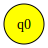

131. Amy's alternatives to peekamyTTu bflipTHu


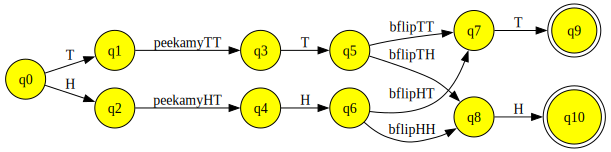

132. Amy's alternatives to peekamyTTu bflipTTu


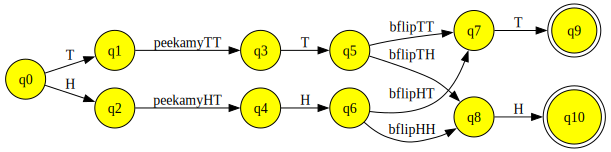

133. Amy's alternatives to peekamyTTu peekamyHHu


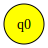

134. Amy's alternatives to peekamyTTu peekamyHTu


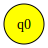

135. Amy's alternatives to peekamyTTu peekamyTHu


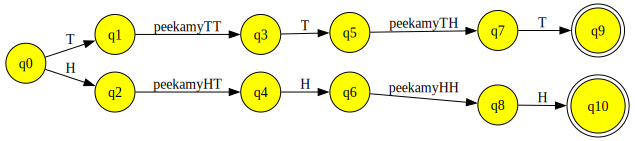

136. Amy's alternatives to peekamyTTu peekamyTTu


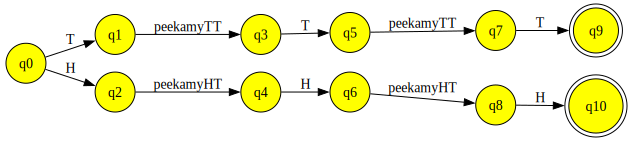

137. Amy's alternatives to peekamyTTu peekbobHHu


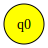

138. Amy's alternatives to peekamyTTu peekbobHTu


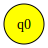

139. Amy's alternatives to peekamyTTu peekbobTHu


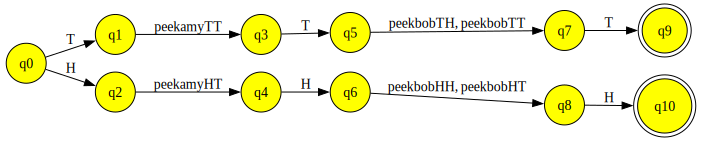

140. Amy's alternatives to peekamyTTu peekbobTTu


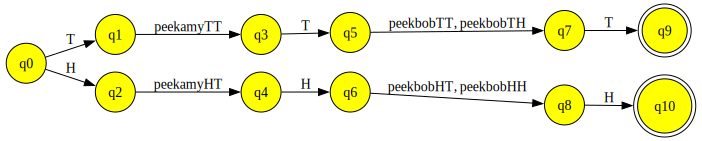

141. Amy's alternatives to peekbobHHu announceHHu


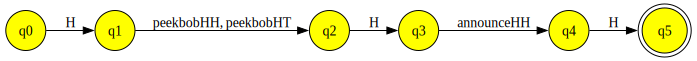

142. Amy's alternatives to peekbobHHu announceTTu


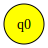

143. Amy's alternatives to peekbobHHu bflipHHu


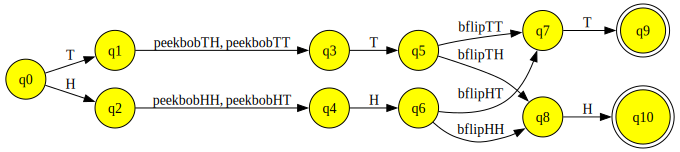

144. Amy's alternatives to peekbobHHu bflipHTu


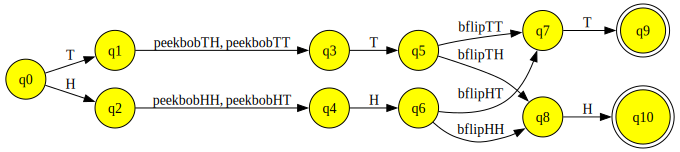

145. Amy's alternatives to peekbobHHu bflipTHu


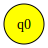

146. Amy's alternatives to peekbobHHu bflipTTu


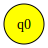

147. Amy's alternatives to peekbobHHu peekamyHHu


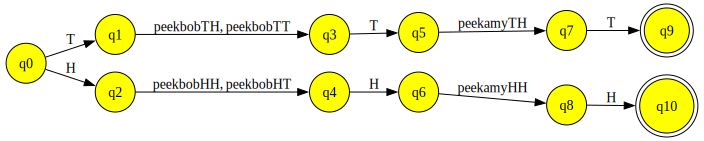

148. Amy's alternatives to peekbobHHu peekamyHTu


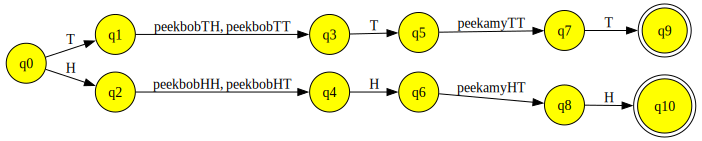

149. Amy's alternatives to peekbobHHu peekamyTHu


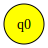

150. Amy's alternatives to peekbobHHu peekamyTTu


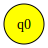

151. Amy's alternatives to peekbobHHu peekbobHHu


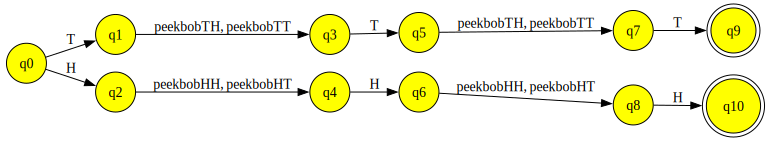

152. Amy's alternatives to peekbobHHu peekbobHTu


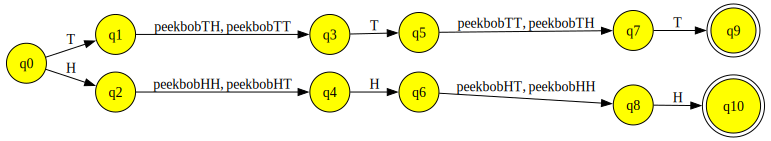

153. Amy's alternatives to peekbobHHu peekbobTHu


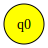

154. Amy's alternatives to peekbobHHu peekbobTTu


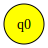

155. Amy's alternatives to peekbobHTu announceHHu


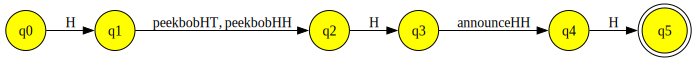

156. Amy's alternatives to peekbobHTu announceTTu


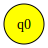

157. Amy's alternatives to peekbobHTu bflipHHu


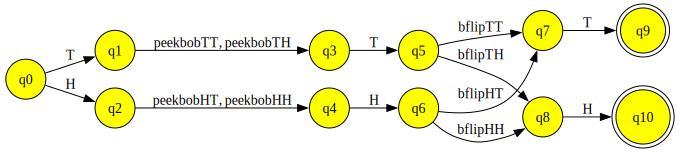

158. Amy's alternatives to peekbobHTu bflipHTu


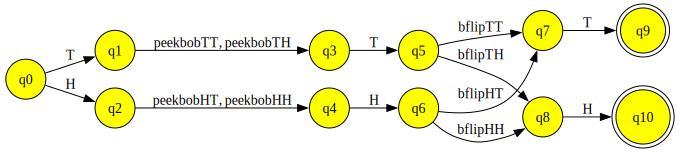

159. Amy's alternatives to peekbobHTu bflipTHu


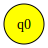

160. Amy's alternatives to peekbobHTu bflipTTu


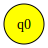

161. Amy's alternatives to peekbobHTu peekamyHHu


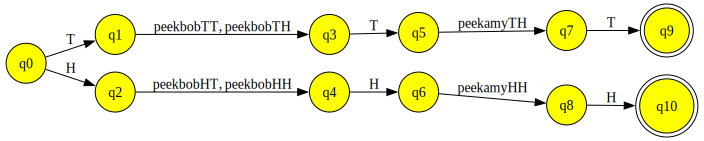

162. Amy's alternatives to peekbobHTu peekamyHTu


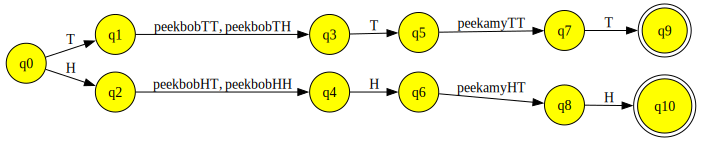

163. Amy's alternatives to peekbobHTu peekamyTHu


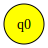

164. Amy's alternatives to peekbobHTu peekamyTTu


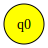

165. Amy's alternatives to peekbobHTu peekbobHHu


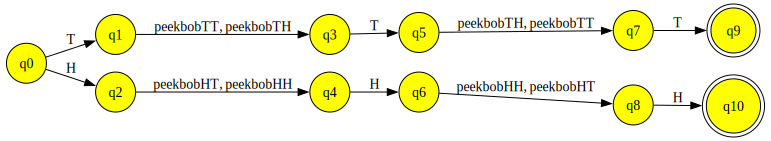

166. Amy's alternatives to peekbobHTu peekbobHTu


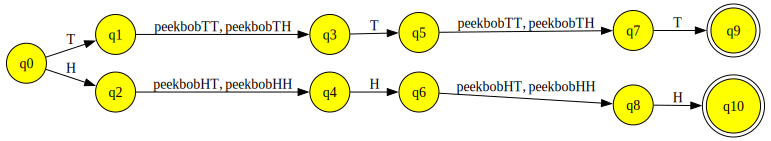

167. Amy's alternatives to peekbobHTu peekbobTHu


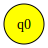

168. Amy's alternatives to peekbobHTu peekbobTTu


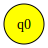

169. Amy's alternatives to peekbobTHu announceHHu


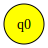

170. Amy's alternatives to peekbobTHu announceTTu


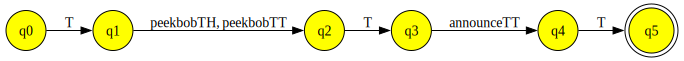

171. Amy's alternatives to peekbobTHu bflipHHu


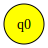

172. Amy's alternatives to peekbobTHu bflipHTu


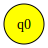

173. Amy's alternatives to peekbobTHu bflipTHu


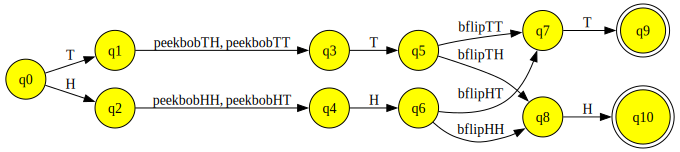

174. Amy's alternatives to peekbobTHu bflipTTu


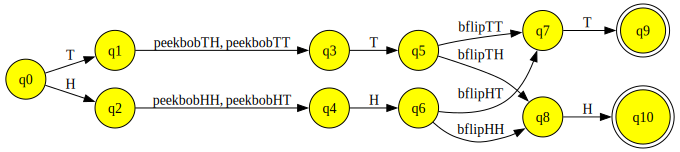

175. Amy's alternatives to peekbobTHu peekamyHHu


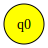

176. Amy's alternatives to peekbobTHu peekamyHTu


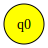

177. Amy's alternatives to peekbobTHu peekamyTHu


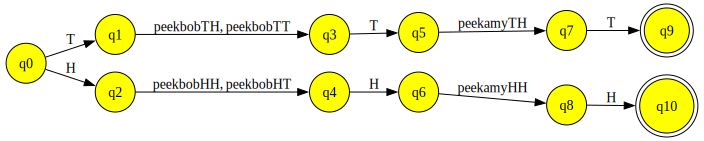

178. Amy's alternatives to peekbobTHu peekamyTTu


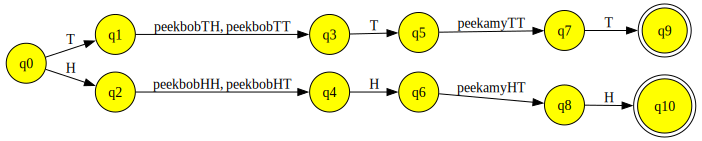

179. Amy's alternatives to peekbobTHu peekbobHHu


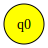

180. Amy's alternatives to peekbobTHu peekbobHTu


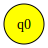

181. Amy's alternatives to peekbobTHu peekbobTHu


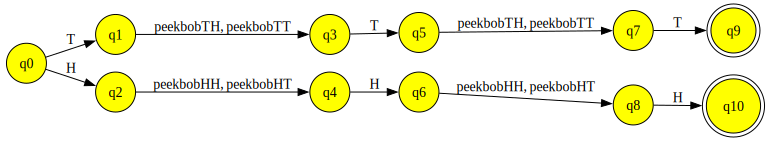

182. Amy's alternatives to peekbobTHu peekbobTTu


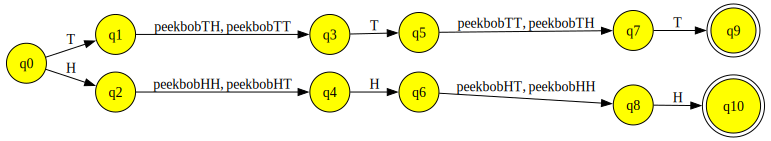

183. Amy's alternatives to peekbobTTu announceHHu


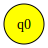

184. Amy's alternatives to peekbobTTu announceTTu


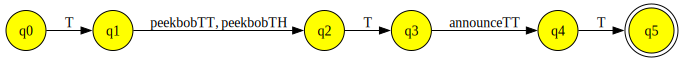

185. Amy's alternatives to peekbobTTu bflipHHu


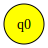

186. Amy's alternatives to peekbobTTu bflipHTu


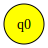

187. Amy's alternatives to peekbobTTu bflipTHu


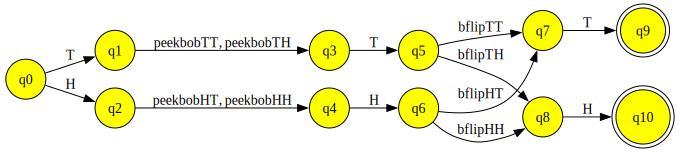

188. Amy's alternatives to peekbobTTu bflipTTu


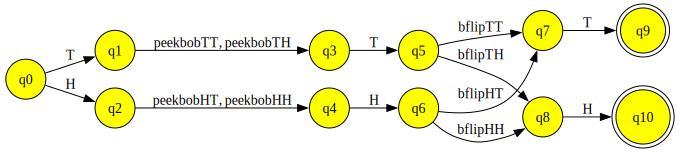

189. Amy's alternatives to peekbobTTu peekamyHHu


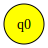

190. Amy's alternatives to peekbobTTu peekamyHTu


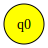

191. Amy's alternatives to peekbobTTu peekamyTHu


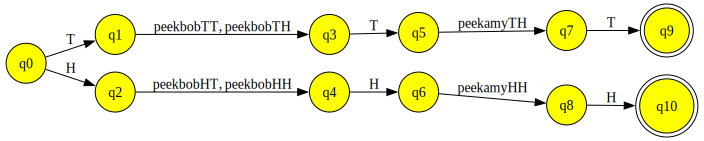

192. Amy's alternatives to peekbobTTu peekamyTTu


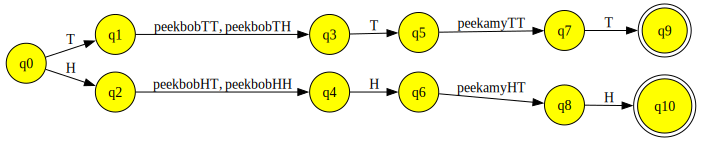

193. Amy's alternatives to peekbobTTu peekbobHHu


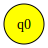

194. Amy's alternatives to peekbobTTu peekbobHTu


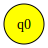

195. Amy's alternatives to peekbobTTu peekbobTHu


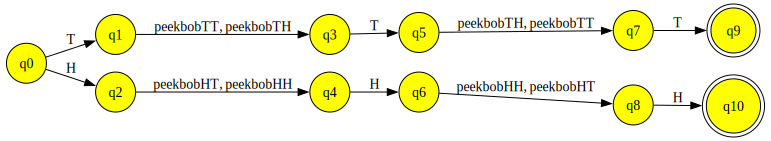

196. Amy's alternatives to peekbobTTu peekbobTTu


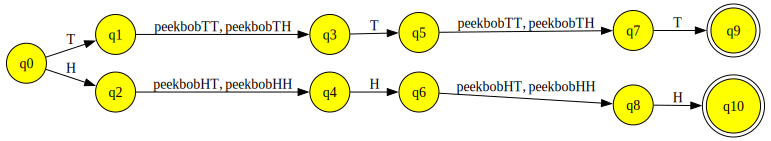

In [188]:
k = 1
for dname in EventNameU:
    dname = dname + "u"
    d = eval(dname)
    for ename in EventNameU:
        ename = ename + "u"
        e = eval(ename)
        de = Cn(d,e)
        print(f'{k}. Amy\'s alternatives to {dname} {ename}')
        image = amyImage(de)
        display(image.view())
        k = k + 1

## Weighted worlds of unconstrained length
We already have W0 defined as follows.

Initial worlds, each with probability 1/2
W0 = weighted_id(1,2)

In [191]:
EventPlus = Event.copy()
EventPlus.kleene_star()

AttributeError: type object 'object' has no attribute '__getattr__'

In [192]:
help(W0)

Help on HfstTransducer in module libhfst_dev object:

class HfstTransducer(builtins.object)
 |  HfstTransducer(*args)
 |  
 |  A synchronous finite-state transducer.
 |  
 |  Methods defined here:
 |  
 |  __del__ lambda self
 |  
 |  __getattr__ lambda self, name
 |  
 |  __init__(self, *args)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  __repr__ = _swig_repr(self)
 |  
 |  __setattr__ lambda self, name, value
 |  
 |  __str__(self)
 |      An AT&T representation of the transducer.
 |      
 |      Defined for print command. An example:
 |      
 |           >>> print(hfst.regex('[foo:bar::2]+'))
 |           0       1       foo     bar     2.000000
 |           1       1       foo     bar     2.000000
 |           1       0.000000 Todo
 |      Works only for small transducers.
 |  
 |  compare(self, arg2, harmonize=True)
 |      Whether this transducer and *another* are equivalent.
 |      
 |      Parameters
 |      ----------
 |      * `another` :